In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append('../')

from minilearn.classifiers import SVM as MiniSVM
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# load saved train and test data
train_df = pd.read_csv('../data/train_features.csv')
test_df = pd.read_csv("../data/test_features.csv")

features_cols = [col for col in train_df.columns if col != 'emotion']

X_train = train_df[features_cols].values
y_train = train_df['emotion'].values

X_test = test_df[features_cols].values
y_test = test_df['emotion'].values

#fix the fearful label mistake
y_train = np.array([label.strip() for label in y_train])
y_test = np.array([label.strip() for label in y_test])

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"Classes: {np.unique(y_train)}")



Training set: (1961, 112)
Test set: (491, 112)
Classes: ['angry' 'calm' 'disgust' 'fearful' 'happy' 'neutral' 'sad' 'surprised']


In [3]:
print("Training Sklearn SVM Linear Kernal")
sklearn_svm_linear = SVC(kernel='linear', C=1.0)
sklearn_svm_linear.fit(X_train, y_train)
linear_preds = sklearn_svm_linear.predict(X_test)
linear_acc = accuracy_score(y_test, linear_preds)
print(f"Linear Kernel Accuracy: {linear_acc:.4f}")

print("\nTraining Sklearn SVM - RBF kernel")
sklearn_svm_rbf = SVC(kernel='rbf', C=1.0, gamma='scale')
sklearn_svm_rbf.fit(X_train, y_train)
rbf_preds = sklearn_svm_rbf.predict(X_test)
rbf_acc = accuracy_score(y_test, rbf_preds)
print(f"RBF kernel accuracy: {rbf_acc:.4f}")

print("\nTraining Sklearn SVM Polynomial Kernel")
sklearn_svm_poly = SVC(kernel='poly', C=1.0, degree=3)
sklearn_svm_poly.fit(X_train, y_train)
poly_preds = sklearn_svm_poly.predict(X_test)
poly_acc = accuracy_score(y_test, poly_preds)
print(f"Poly kernel accuracy: {poly_acc:.4f}")


Training Sklearn SVM Linear Kernal
Linear Kernel Accuracy: 0.6314

Training Sklearn SVM - RBF kernel
RBF kernel accuracy: 0.6884

Training Sklearn SVM Polynomial Kernel
Poly kernel accuracy: 0.5479


In [4]:
from sklearn.model_selection import GridSearchCV

# tune C and gamma for RBF kernel
param_grid = {
    'C': [0.1, 1, 10, 100], 
    'gamma': ['scale', 'auto', 0.001, 0.01]
}

print("Running GridSearch for RBF SVM")
grid_search = GridSearchCV(SVC(kernel='rbf'), param_grid, cv=5, scoring='accuracy', verbose=1)
grid_search.fit(X_train, y_train)

print(f"\nBest Parameters: {grid_search.best_params_}")
print(f"best Cross Validation Accuracy: {grid_search.best_score_:.4f}")

#test with best parameters
best_svm = grid_search.best_estimator_
best_preds=best_svm.predict(X_test)
best_acc = accuracy_score(y_test, best_preds)
print(f"Test Accuracy with best Parameters: {best_acc:.4f}")

Running GridSearch for RBF SVM
Fitting 5 folds for each of 16 candidates, totalling 80 fits

Best Parameters: {'C': 10, 'gamma': 'scale'}
best Cross Validation Accuracy: 0.7257
Test Accuracy with best Parameters: 0.7515


In [5]:
print("Training Minilearn SVM")
mini_svm=MiniSVM(learning_rate=0.001, lambda_param=0.01, n_iterations=1000)
mini_svm.fit(X_train, y_train)
mini_svm_preds = mini_svm.predict(X_test)
mini_svm_acc = accuracy_score(y_test, mini_svm_preds)
print(f"MiniLearn SVM Accuracy: {mini_svm_acc:.4f}")

Training Minilearn SVM
MiniLearn SVM Accuracy: 0.5764


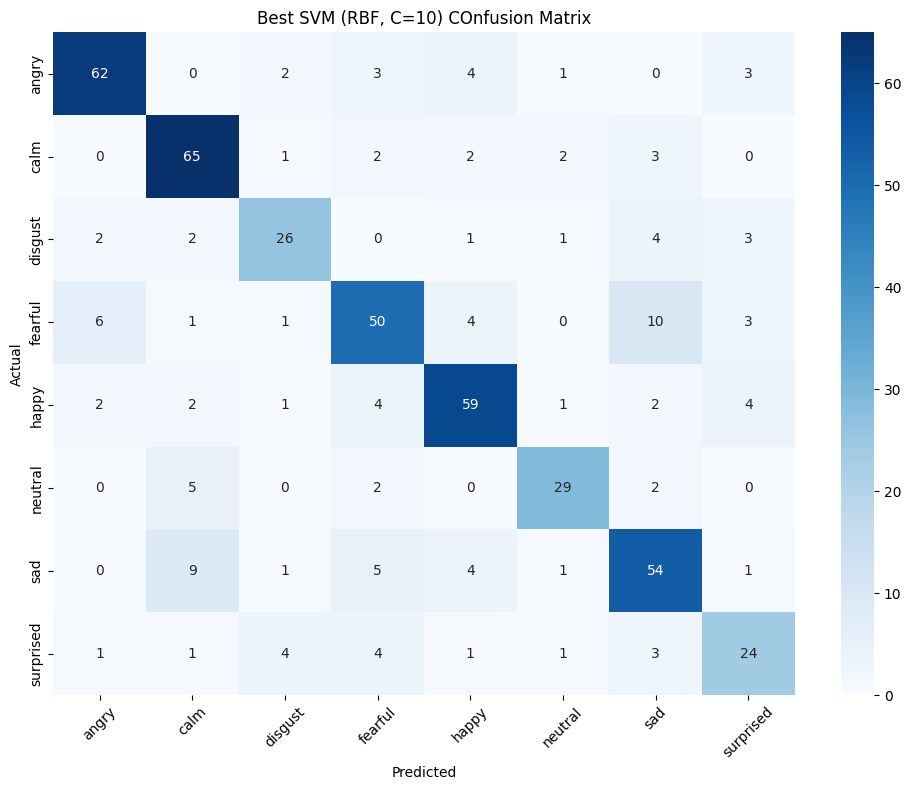

best SVM classification Report
              precision    recall  f1-score   support

       angry       0.85      0.83      0.84        75
        calm       0.76      0.87      0.81        75
     disgust       0.72      0.67      0.69        39
     fearful       0.71      0.67      0.69        75
       happy       0.79      0.79      0.79        75
     neutral       0.81      0.76      0.78        38
         sad       0.69      0.72      0.71        75
   surprised       0.63      0.62      0.62        39

    accuracy                           0.75       491
   macro avg       0.75      0.74      0.74       491
weighted avg       0.75      0.75      0.75       491



In [6]:
plt.figure(figsize=(10,8))
cm = confusion_matrix(y_test, best_preds, labels=np.unique(y_test))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.title("Best SVM (RBF, C=10) COnfusion Matrix")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print('best SVM classification Report')
print(classification_report(y_test, best_preds))
